In [1]:
import util.DataGen

"""
See the behavior of Normalized Xcorr used for OpenCV template matching. Obviously this should only work for
Independent pulses but might be a better baseline detector for independent...

https://docs.opencv.org/4.x/df/dfb/group__imgproc__object.html#gga3a7850640f1fe1f58fe91a2d7583695dac5babb7dfda59544e3e31ea928f8cb16

"""

'\nSee the behavior of Normalized Xcorr used for OpenCV template matching. Obviously this should only work for\nIndependent pulses but might be a better baseline detector for independent...\n\nhttps://docs.opencv.org/4.x/df/dfb/group__imgproc__object.html#gga3a7850640f1fe1f58fe91a2d7583695dac5babb7dfda59544e3e31ea928f8cb16\n\n'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

from util.Processing import td_nnlsr_deconvolve

from sklearn.covariance import EllipticEnvelope

In [3]:
def load_strange_xtr(file):
    traces = []
    
    with open(file, 'r', encoding='UTF-8') as file:
        while line := file.readline():
            line = line.rstrip()
            if 'eRC' not in line:
                continue
            line = '{' + line.split('{')[-1]
            dict_ = eval(line)
            traces.append(np.array(dict_['pulse']))
    return traces

def normed_xcorr(trace, kernel):
    # Taken from OpenCV 2D image processing template matching...
    # https://docs.opencv.org/4.x/df/dfb/group__imgproc__object.html
    
    return np.correlate(trace, kernel, mode='valid')
    
    # This works terribly...
    # corr = np.correlate(trace, kernel, mode='valid')
    # square_corr = np.correlate(trace ** 2, kernel ** 2, mode='valid')
    # return corr / square_corr
        
    

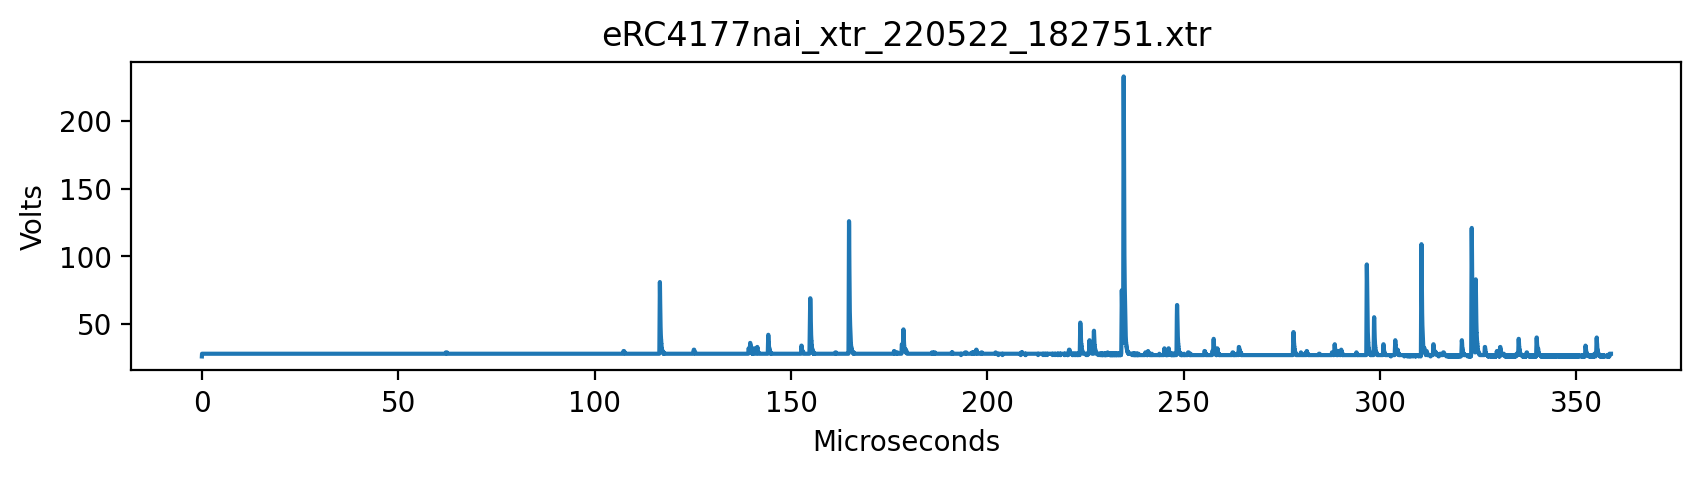

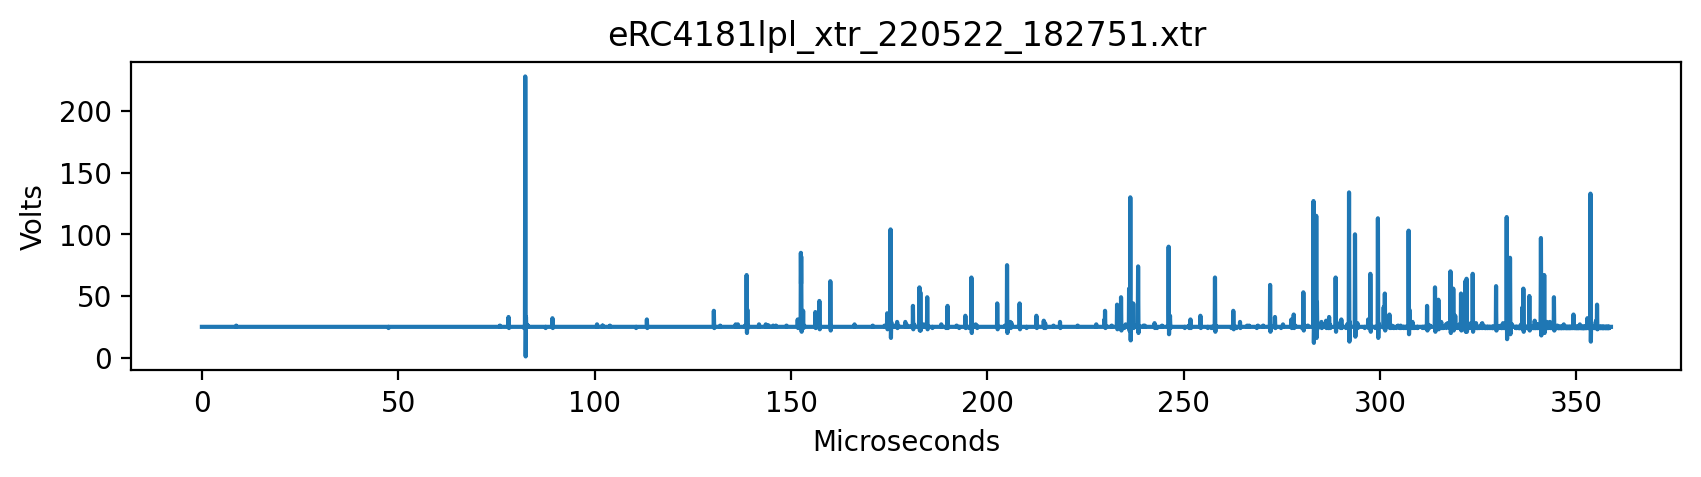

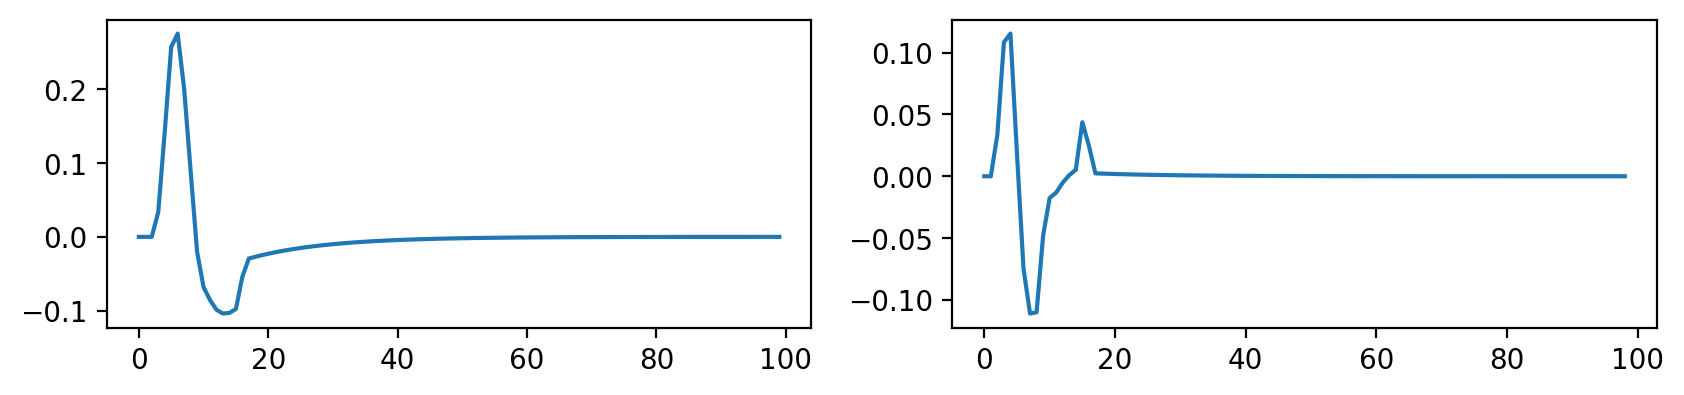

In [4]:
files = ['eRC4177nai_xtr_220522_182751.xtr', 'eRC4181lpl_xtr_220522_182751.xtr']

fs = 80E6
dt = 1 / fs

MICRO = 1E6

fig, axes = plt.subplots(1,1,figsize=(10,2), dpi=200)
axes.set_xlabel('Microseconds')
axes.set_ylabel('Volts')

trace = load_strange_xtr(files[0])[0]
time = dt * np.arange(trace.size)
micro = time * MICRO
axes.plot(micro, trace)
axes.set_title(files[0])

fig, axes = plt.subplots(1,1,figsize=(10,2), dpi=200)
axes.set_xlabel('Microseconds')
axes.set_ylabel('Volts')

trace = load_strange_xtr(files[1])[0]
time = dt * np.arange(trace.size)
micro = time * MICRO
axes.plot(micro, trace)
axes.set_title(files[1])
    
# t = 80
# axes.set_xlim(t,t+10)
# # axes.set_ylim(0, 150)


_, temp_kernel = util.DataGen.nai_pulse(1)
conv_kernel_dt = np.diff(temp_kernel)
conv_kernel_d2t2 = np.diff(np.diff(temp_kernel))

fig, axes = plt.subplots(1,2,figsize=(10,2), dpi=200)
axes[0].plot(conv_kernel_dt)
axes[1].plot(conv_kernel_d2t2)

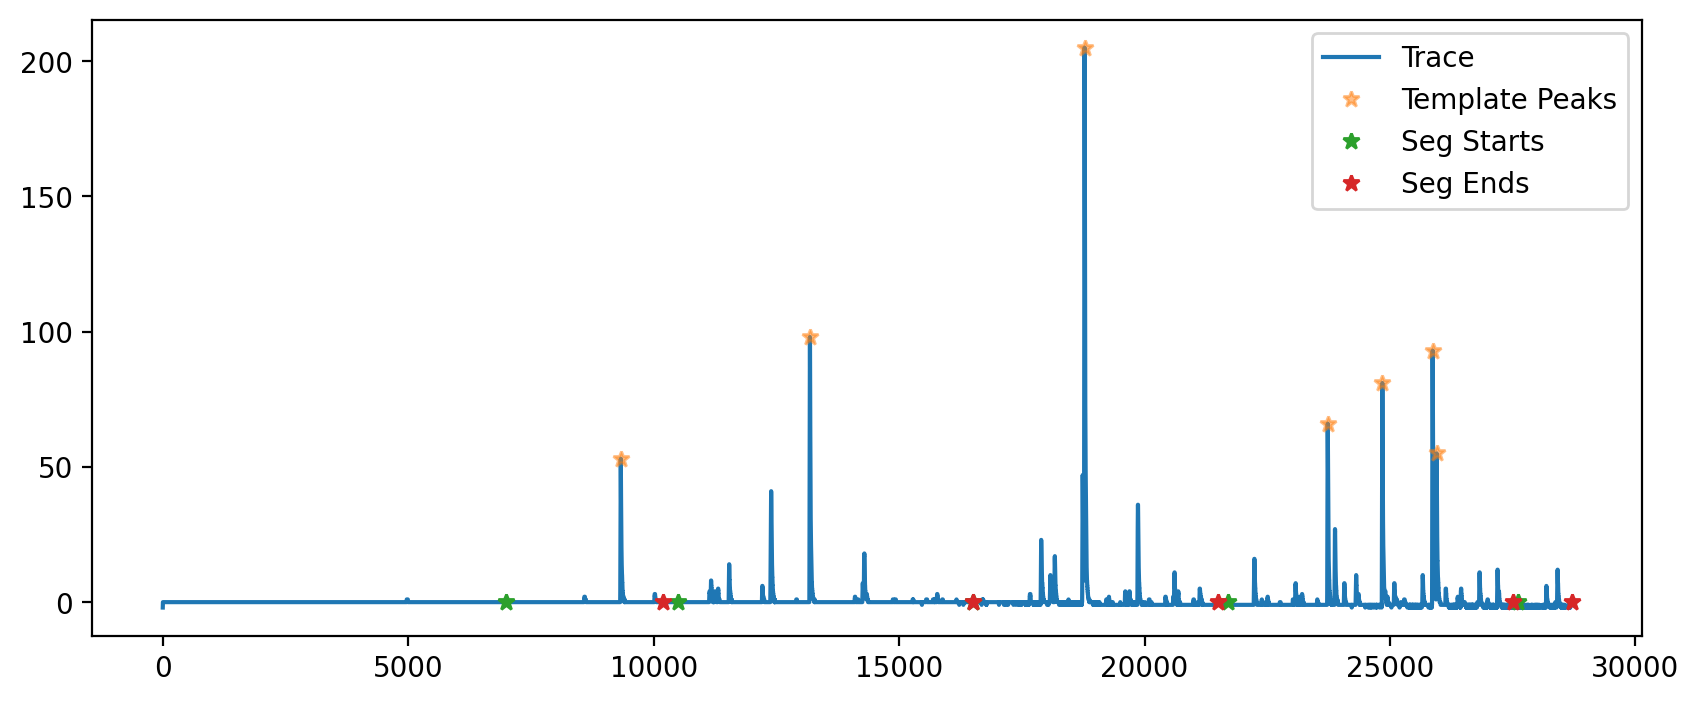

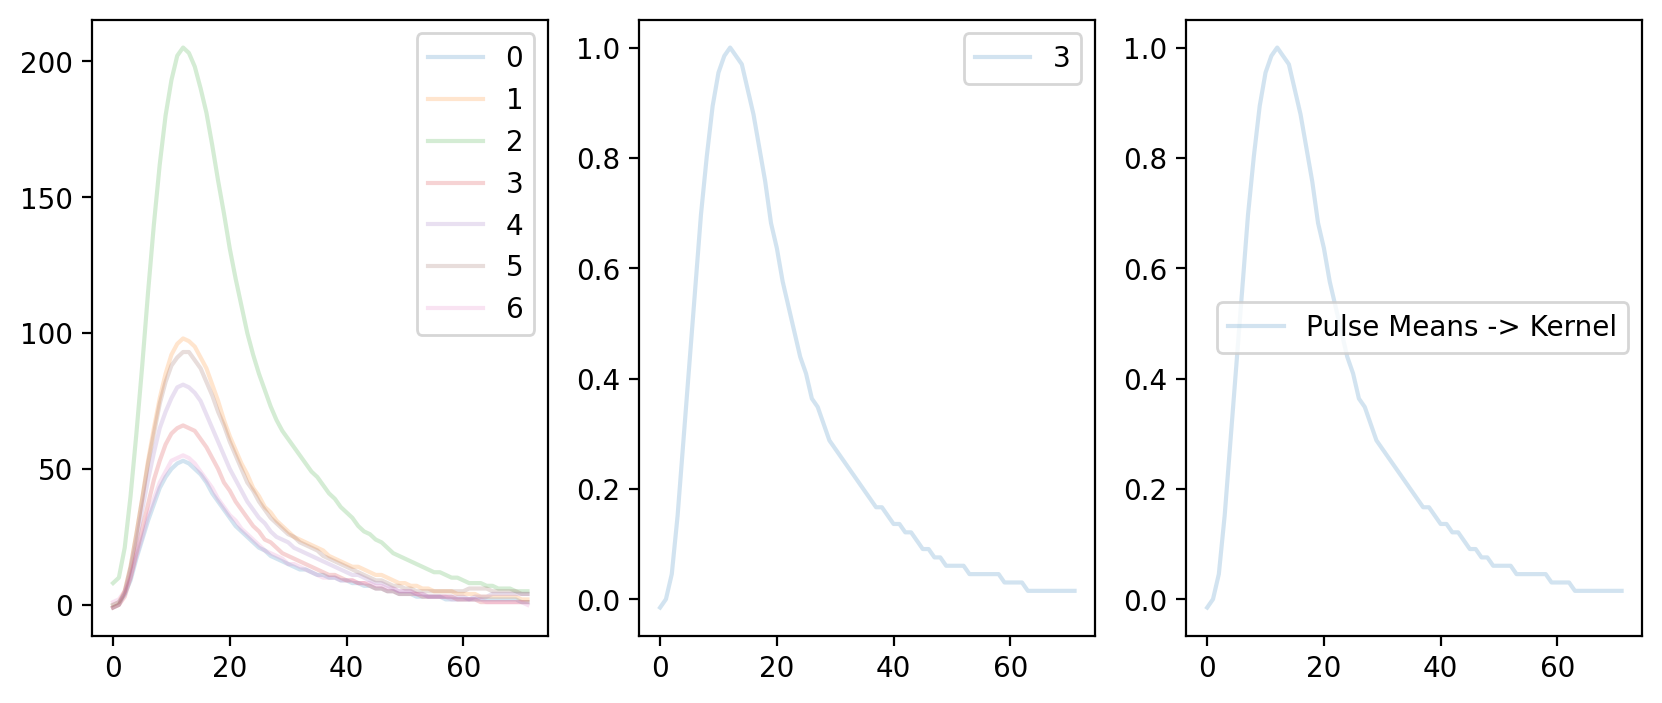

In [5]:
trace = load_strange_xtr(files[0])[0]
baseline,_ = scipy.stats.mode(trace, keepdims=False)
trace = trace - baseline
index = np.arange(trace.size)
microseconds = dt * index * MICRO

limit1 = 50
segment_bounds = [
    (7000, 10200),
    (10500, 16500),
    (16500, 21500),
    (21700, 27500),
    (27600, trace.size-1)
    ]

argpeaks, _ = scipy.signal.find_peaks(trace)
argpeaks = argpeaks[trace[argpeaks] > limit1]

fig, axis = plt.subplots(1,1,figsize=(10,4), dpi=200)
axis.plot(index, trace, label='Trace')
axis.plot(index[argpeaks], trace[argpeaks], '*', alpha=.5, label='Template Peaks')

seg_bounds_npy = np.array(segment_bounds)
axis.plot(seg_bounds_npy[:,0], np.zeros_like(seg_bounds_npy[:,0]), '*', alpha=1, label='Seg Starts')
axis.plot(seg_bounds_npy[:,1], np.zeros_like(seg_bounds_npy[:,1]), '*', alpha=1, label='Seg Ends')
axis.legend()

skip_peaks = [0,1,2,4,5,6]
template_pulses = []
fig, axes = plt.subplots(1,3,figsize=(10,4), dpi=200)
for i, argpeak in enumerate(argpeaks.tolist()):
    try:
        pulse = trace[argpeak - 12 : argpeak + 60]
        axes[0].plot(pulse, alpha=.2, label=i)
        
        if i in skip_peaks:
            continue
        
        pulse = pulse / np.max(pulse)
        template_pulses.append(pulse)
        axes[1].plot(pulse, alpha=.2, label=i)
    except:
        pass
    
kernel = np.mean(np.stack(template_pulses), axis=0)

if argpeaks.size < 100:
    axes[0].legend()
    axes[1].legend()

axes[2].plot(kernel, alpha=.2, label='Pulse Means -> Kernel')
axes[2].legend()


28705 28704


(-50.0, 50.0)

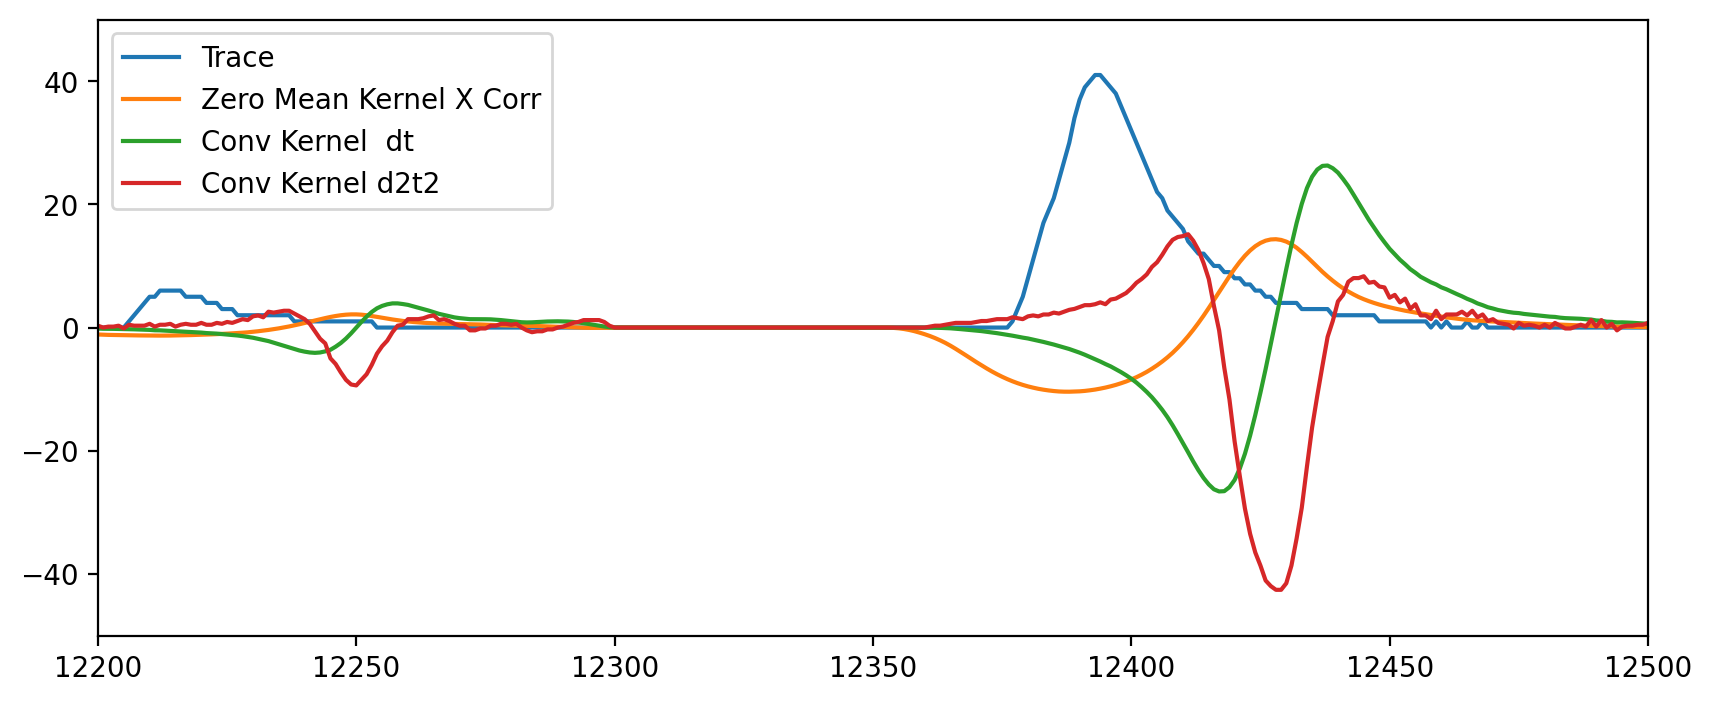

In [20]:
fig, axis = plt.subplots(1,1,figsize=(10,4), dpi=200)

peak_offset = np.argmax(kernel)
zmean_kernel = kernel - np.mean(kernel)
nxcor = normed_xcorr(trace, zmean_kernel)

axis.plot(np.arange(trace.size), trace, label='Trace')
corr_offset = (trace.size - nxcor.size) // 2
axis.plot(np.arange(nxcor.size) + corr_offset + peak_offset, nxcor/20, label='Zero Mean Kernel X Corr')


#Derivatives Correlation
conv_kernel_dt = np.correlate(trace, np.diff(kernel), mode='valid')
conv_kernel_d2t2 = np.correlate(trace, np.diff(np.diff(kernel)), mode='valid')

kernel_dt_offset = (trace.size - conv_kernel_dt.size) // 2
kernel_d2t2_offset = (trace.size - conv_kernel_d2t2.size) // 2
corr_peak_offset = conv_kernel_dt.size // 2

axis.plot(np.arange(conv_kernel_dt.size) + kernel_dt_offset + peak_offset, conv_kernel_dt, label='Conv Kernel  dt')
axis.plot(np.arange(conv_kernel_d2t2.size) + kernel_d2t2_offset + peak_offset, 10 * conv_kernel_d2t2, label='Conv Kernel d2t2')


# Kernel derivatives correlated with trace derivatives...
trace_dt = np.diff(trace)
trace_d2t2 = np.diff(trace_dt)
conv_slide_dt_kernel_dt = np.correlate(trace_dt, np.diff(kernel), mode='same')
conv_slice_d2t2_kernel_d2t2 = np.correlate(trace_d2t2, np.diff(np.diff(kernel)), mode='same')

corr_offset = (trace.size - nxcor.size) // 2
corr_peak_offset = conv_kernel_dt.size // 2

print(conv_slide_dt_kernel_dt.size,conv_slice_d2t2_kernel_d2t2.size )

# axis.plot(np.arange(conv_slide_dt_kernel_dt.size)  + peak_offset - corr_peak_offset, 5 * conv_slide_dt_kernel_dt, label='Conv Kernel dt')
# axis.plot(np.arange(conv_slice_d2t2_kernel_d2t2.size) + peak_offset, 50 * conv_slice_d2t2_kernel_d2t2, label='Conv Kernel d2t2')


start = 12200
width = 300
axis.set_xlim(start, start+width)
axis.legend()
axis.set_ylim(-50, 50)

In [7]:
"""
CONCLUSION: None of these are even as good as just finding the correlation with the zero-mean-subkernel around peak...
"""

'\n\nCONCLUSION: None of these are even as good as just finding the correlation with the zero-mean-subkernel around peak...\n'